# **Model 5 Parameters:**
## **Inputs:** SMILES strings of chemical structures and experimental DMSO-normalized ZBTB11 and IKZF1 abundance values at 10 test MGD concentrations (%)
## **Outputs:** Predicted ZBTB11 and IKZF1 abundance values at each MGD concentration (%)
## **Approach:** Multi-target Chemprop v2 with Optuna wrapper for hyperparameter tuning and Hybrid MSE Curve Fitting + Contrastive Learning Loss Function
## **Baseline:** Ridge Regression on Morgan fingerprints
### Data splitting by computed Bemis-Murcko scaffolds using astartes package
* 80/10/10% train/validation/test

**Package installs and file loading**

In [1]:
# from google.colab import drive
# import os

# drive.mount('/content/drive')
# %cd "/content/drive/MyDrive/Colab Notebooks/ZBTB11 Degraders/model3"

In [2]:
!pip install optuna lightning chemprop ipywidgets umap-learn matplotlib seaborn

In [3]:
!pip install torch --index-url https://download.pytorch.org/whl/cu130

Looking in indexes: https://download.pytorch.org/whl/cu130


In [4]:
!pip install pytorch-metric-learning

In [29]:
# General Use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Standard Machine Learning & Viz
import umap
import optuna
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

# Cheminformatics
from rdkit import Chem
from rdkit.Chem import AllChem

# Deep Learning Frameworks
import torch
import torch.nn as torch_nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from lightning import pytorch as pl
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

# Chemprop (V2)
from chemprop import data, featurizers, models, nn
from chemprop.models import MPNN

# Custom Loss
from pytorch_metric_learning.losses import NTXentLoss

**Synthetic Data Generation**

Uncomment code chunk below if you want to test code adjustments with randomly generated dataset

In [6]:
# print("Generating synthetic molecular glue dataset...")

# # 1. Generate 100 valid SMILES strings
# # We use a basic amide-phenyl scaffold and grow an aliphatic chain to create unique molecules
# smiles_list = [f"O=C(Nc1ccccc1)C{'C'*i}" for i in range(1, 41)] + \
#               [f"O=C(Nc1ccc(Cl)cc1)C{'C'*i}" for i in range(1, 31)] + \
#               [f"O=C(Nc1ccc(F)cc1)C{'C'*i}" for i in range(1, 31)]

# df = pd.DataFrame({'SMILES': smiles_list})

# # 2. Assign distinct splits (70 Train / 15 Val / 15 Test)
# df['Dataset'] = ['Train'] * 70 + ['Val'] * 15 + ['Test'] * 15

# # 3. Generate dummy ZBTB11 data
# # pDC50 between 5.0 (10 uM) and 9.0 (1 nM), Dmax between 20% and 100%
# np.random.seed(42) # For reproducible random numbers
# df['ZBTB11_pDC50'] = np.random.uniform(5.0, 9.0, 100)
# df['ZBTB11_Dmax'] = np.random.uniform(20.0, 100.0, 100)

# # 4. Generate dummy IKZF1 data
# df['IKZF1_pDC50'] = np.random.uniform(4.0, 8.0, 100)
# df['IKZF1_Dmax'] = np.random.uniform(0.0, 100.0, 100)

# # 5. Inject 'NaN' values to simulate Inactive Compounds
# # Let's pick 10 random molecules and make them completely inactive against IKZF1
# inactive_indices = np.random.choice(100, 10, replace=False)
# df.loc[inactive_indices, 'IKZF1_Dmax'] = 0.0
# df.loc[inactive_indices, 'IKZF1_pDC50'] = np.nan # This tests Chemprop's masking feature!

# # 6. Save to CSV
# csv_filename = "zbtb11_mgd_input.csv"
# df.to_csv(csv_filename, index=False)

# print(f"Successfully saved 100 test molecules to '{csv_filename}'.")
# print("\nSample of the generated data:")
# print(df.head())

**Data Splitting and Loading**

In [7]:
def assign_supcon_classes(df, z_auc_col, i_auc_col, active_max_auc, selectivity_margin):
    z_auc = df[z_auc_col]
    i_auc = df[i_auc_col]
    
    cond_inactive = (z_auc > active_max_auc) & (i_auc > active_max_auc)
    cond_z_selective = (z_auc <= active_max_auc) & ((i_auc > active_max_auc) | ((i_auc - z_auc) >= selectivity_margin))
    cond_i_selective = (i_auc <= active_max_auc) & ((z_auc > active_max_auc) | ((z_auc - i_auc) >= selectivity_margin))
    cond_dual = (z_auc <= active_max_auc) & (i_auc <= active_max_auc) & (abs(z_auc - i_auc) < selectivity_margin)
    
    choices = [0, 1, 2, 3]
    df['SupCon_Class'] = np.select([cond_inactive, cond_z_selective, cond_i_selective, cond_dual], choices, default=0)
    
    print("\n--- SupCon Class Distribution ---")
    print(df['SupCon_Class'].value_counts().sort_index())
    return df

def smiles_to_morgan(smiles_list, radius=2, n_bits=2048):
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fps.append(np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)))
        else:
            fps.append(np.zeros((n_bits,)))
    return np.array(fps)


# 1. LOAD FULL DATASET, DEFINE 20 TARGETS, AND ASSIGN AUC LABELS
df = pd.read_csv("zbtb11_mgd_input.csv")

concs = ['3nM', '10nM', '30nM', '100nM', '300nM', '1uM', '3uM', '10uM', '30uM', '100uM']
targets = [f'zbtb11_{c}' for c in concs] + [f'ikzf1_{c}' for c in concs]

def clean_assay_data(df, target_cols):
    df[target_cols] = df[target_cols].apply(pd.to_numeric, errors='coerce')
    df[target_cols] = df[target_cols].clip(lower=0, upper=100)              
    return df.dropna(subset=target_cols, how='all')                         

df = clean_assay_data(df, targets)

conc_nM = [3, 10, 30, 100, 300, 1000, 3000, 10000, 30000, 100000]
log_conc = np.log10(conc_nM)

zbtb11_cols = [f'zbtb11_{c}' for c in concs]
ikzf1_cols = [f'ikzf1_{c}' for c in concs]

df['True_ZBTB11_AUC'] = df[zbtb11_cols].apply(lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1)
df['True_IKZF1_AUC'] = df[ikzf1_cols].apply(lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1)

df = assign_supcon_classes(df, 'True_ZBTB11_AUC', 'True_IKZF1_AUC', active_max_auc=400.0, selectivity_margin=150.0)
df.to_csv("zbtb11_mgd_auc_labels_input.csv", index=False)

smiles_list = df['SMILES'].tolist()
y_values = df[targets + ['SupCon_Class']].values


# 2. CREATE CHEM PROP DATAPOINTS & GENERATE SCAFFOLD SPLIT
all_datapoints = [
    data.MoleculeDatapoint.from_smi(smi, y) 
    for smi, y in zip(smiles_list, y_values)
]

all_mols = [d.mol for d in all_datapoints]
train_idx, val_idx, test_idx = data.make_split_indices(
    all_mols,
    split="scaffold_balanced", 
    sizes=(0.8, 0.1, 0.1), 
    seed=42
)


# 3. APPLY INDICES TO CHEM PROP (DEEP LEARNING PREP)
train_data, val_data, test_data = data.split_data_by_indices(
    all_datapoints, train_idx, val_idx, test_idx
)

featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
train_dset = data.MoleculeDataset(train_data[0], featurizer)
val_dset = data.MoleculeDataset(val_data[0], featurizer)
test_dset = data.MoleculeDataset(test_data[0], featurizer)

output_scaler = train_dset.normalize_targets()

if output_scaler is not None:
    try:
        output_scaler.means[-1] = 0.0
        output_scaler.stds[-1] = 1.0
    except AttributeError:
        output_scaler.mean_[-1] = 0.0
        output_scaler.scale_[-1] = 1.0
        
val_dset.normalize_targets(output_scaler)
test_dset.normalize_targets(output_scaler)

train_loader = DataLoader(
    train_dset,             
    batch_size=32,         
    shuffle=True,           
    collate_fn=data.collate_batch, 
    drop_last=True          
)

val_loader = DataLoader(
    val_dset,               
    batch_size=32,         
    shuffle=False,          
    collate_fn=data.collate_batch,   
    drop_last=False         
)

test_loader = DataLoader(
    test_dset,              
    batch_size=32,
    shuffle=False,
    collate_fn=data.collate_batch,  
    drop_last=False
)


# 4. APPLY INDICES TO PANDAS/SCIKIT-LEARN (CLASSICAL ML PREP)
train_idx_flat = np.array(train_idx).flatten()
test_idx_flat = np.array(test_idx).flatten()

train_df = df.iloc[train_idx_flat].copy()
test_df = df.iloc[test_idx_flat].copy()

X_train = smiles_to_morgan(train_df['SMILES'].tolist())
X_test = smiles_to_morgan(test_df['SMILES'].tolist())

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print("Unified data preparation complete!")

The return type of make_split_indices has changed in v2.1 - see help(make_split_indices)



--- SupCon Class Distribution ---
SupCon_Class
0    20
2    47
3    21
Name: count, dtype: int64
Unified data preparation complete!


C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\astartes\main.py:325: ImperfectSplittingWarning: Actual train/test split differs from requested size. Requested train size of 0.80, got 0.82. Requested validation size of 0.10, got 0.09. Requested test size of 0.10, got 0.09. 
  warn(
[15:44:54] DEPRECATION WARNING: please use MorganGenerator
[15:44:54] DEPRECATION WARNING: please use MorganGenerator
[15:44:54] DEPRECATION WARNING: please use MorganGenerator
[15:44:54] DEPRECATION WARNING: please use MorganGenerator
[15:44:54] DEPRECATION WARNING: please use MorganGenerator
[15:44:54] DEPRECATION WARNING: please use MorganGenerator
[15:44:54] DEPRECATION WARNING: please use MorganGenerator
[15:44:54] DEPRECATION WARNING: please use MorganGenerator
[15:44:54] DEPRECATION WARNING: please use MorganGenerator
[15:44:54] DEPRECATION WARNING: please use MorganGenerator
[15:44:54] DEPRECATION WARNING: please use MorganGenerator
[15:44:54] DEPRECATION WARNING: please use 

**Baseline Ridge Regression Model Training and Evaluation**


--- Top Predicted Selective Compounds ---
                                               SMILES  \
73  O=C1C2=CC=C(NC(CN(CC3)CCN3C4=CC=C(OC)C=C4)=O)C...   
69  O=C1C2=CC=C(NC(CN(CCCC3=CC=C(OC)C=C3)C4CCCC4)=...   
77  O=C1CCC(N2C(C(C=CC(NC(NC3(CCCC3)C(NCCC4=CC=C(O...   
46  O=C(N1)CCC(N2C(C(NC3=CC(C4(CCC4)NCC5=CC(S(=O)(...   
45  O=C(N1)CCC(N2C(C(NC3=CC(C4(CCC4)NCC5=CC=C(S(=O...   

    Pred_ZBTB11_Selectivity  True_ZBTB11_Selectivity  Pred_ZBTB11_AUC  \
73               -33.934756              -222.320777       433.625188   
69               -58.226386              -288.607287       428.705444   
77              -109.273555              -141.692576       415.451101   
46              -110.097523                 1.011474       411.931851   
45              -117.039719                 2.552514       391.920451   

    True_ZBTB11_AUC  
73       450.723594  
69       436.649134  
77       438.465436  
46       420.347358  
45       404.461537  


C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


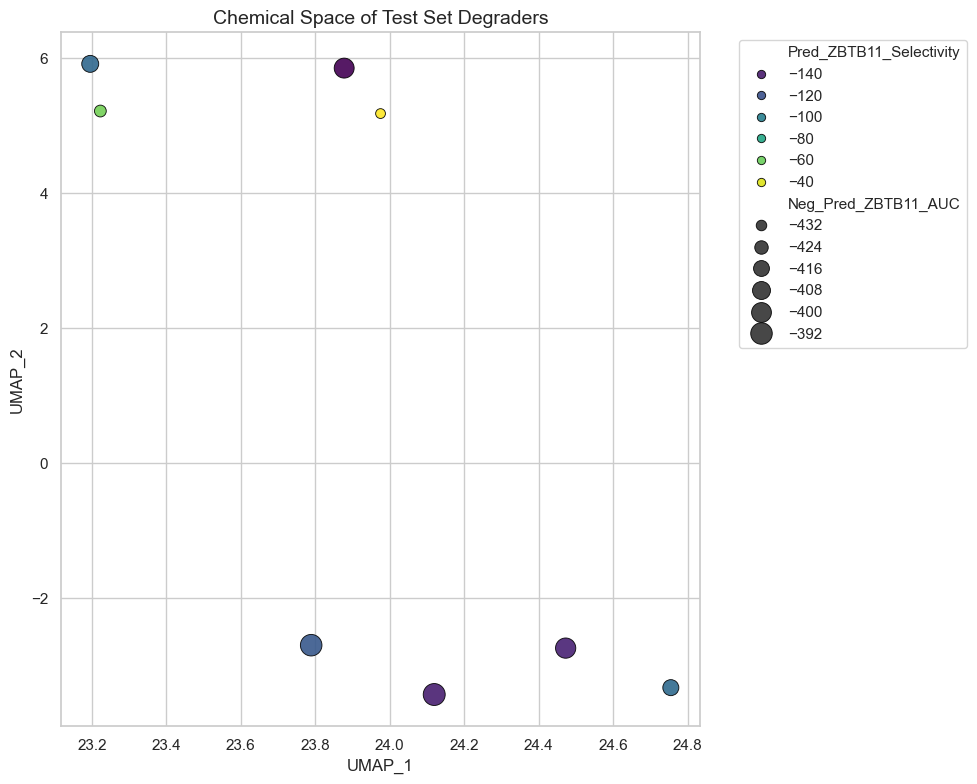


Overall Average Across All Concentrations -> RMSE: 17.942 | R²: -5.830

--- Baseline Regression Metrics (Per Concentration) ---
    Endpoint  N_Valid   RMSE    MAE      R²  Pearson_r
  zbtb11_3nM        8  1.195  1.033   0.137      0.581
 zbtb11_10nM        8  1.970  1.838  -0.815     -0.041
 zbtb11_30nM        8  3.450  3.325 -17.556      0.493
zbtb11_100nM        8  5.238  5.002  -4.078      0.756
zbtb11_300nM        8  7.750  7.639 -31.086      0.722
  zbtb11_1uM        8 10.391  9.919 -47.069     -0.291
  zbtb11_3uM        8  8.890  8.518  -6.557      0.655
 zbtb11_10uM        8  5.860  5.141  -0.744      0.715
 zbtb11_30uM        8  8.838  7.613   0.637      0.855
zbtb11_100uM        8 21.262 17.588   0.402      0.871
   ikzf1_3nM        8  6.711  4.373  -0.162     -0.279
  ikzf1_10nM        8 14.243 11.192  -0.144     -0.345
  ikzf1_30nM        8 27.878 23.366  -0.639     -0.627
 ikzf1_100nM        8 32.992 28.390  -0.800     -0.585
 ikzf1_300nM        8 35.422 31.453  -0.982   

In [8]:
conc_molar = [3e-9, 10e-9, 30e-9, 100e-9, 300e-9, 1e-6, 3e-6, 10e-6, 30e-6, 100e-6]
log_conc = np.log10(conc_molar)


# 1. TRAIN 20 INDEPENDENT RIDGE MODELS
trained_models = {}
alphas = [0.1, 1.0, 10.0, 100.0, 1000.0]

for target in targets:
    y_train = train_df[target].values
    valid_mask = ~np.isnan(y_train)
    
    if valid_mask.sum() > 5:
        model = RidgeCV(alphas=alphas, cv=5)
        model.fit(X_train_scaled[valid_mask], y_train[valid_mask])
        trained_models[target] = model
    else:
        print(f"Warning: Not enough data for {target}. Skipping.")


# 2. PREDICT AND CALCULATE TRUE AREA UNDER CURVE (AUC)

true_target_cols = list(trained_models.keys())
test_results_df = test_df[['SMILES'] + true_target_cols].copy()

for target in trained_models.keys():
    test_results_df[f'Pred_{target}'] = trained_models[target].predict(X_test_scaled)

pred_zbtb11_cols = [f'Pred_zbtb11_{c}' for c in concs if f'zbtb11_{c}' in trained_models]
pred_ikzf1_cols = [f'Pred_ikzf1_{c}' for c in concs if f'ikzf1_{c}' in trained_models]

true_zbtb11_cols = [f'zbtb11_{c}' for c in concs if f'zbtb11_{c}' in trained_models]
true_ikzf1_cols = [f'ikzf1_{c}' for c in concs if f'ikzf1_{c}' in trained_models]

zbtb11_x = [log_conc[i] for i, c in enumerate(concs) if f'zbtb11_{c}' in trained_models]
ikzf1_x = [log_conc[i] for i, c in enumerate(concs) if f'ikzf1_{c}' in trained_models]

test_results_df['Pred_ZBTB11_AUC'] = test_results_df[pred_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=zbtb11_x), axis=1
)
test_results_df['Pred_IKZF1_AUC'] = test_results_df[pred_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=ikzf1_x), axis=1
)

test_results_df['True_ZBTB11_AUC'] = test_results_df[true_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=zbtb11_x), axis=1
)
test_results_df['True_IKZF1_AUC'] = test_results_df[true_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=ikzf1_x), axis=1
)

test_results_df['Pred_ZBTB11_Selectivity'] = test_results_df['Pred_IKZF1_AUC'] - test_results_df['Pred_ZBTB11_AUC']
test_results_df['True_ZBTB11_Selectivity'] = test_results_df['True_IKZF1_AUC'] - test_results_df['True_ZBTB11_AUC']

test_results_df = test_results_df.sort_values(by='Pred_ZBTB11_Selectivity', ascending=False)
test_results_df.to_csv("zbtb11_mgd_ridge_output.csv", index=False)

print("\n--- Top Predicted Selective Compounds ---")
print(test_results_df[['SMILES', 'Pred_ZBTB11_Selectivity', 'True_ZBTB11_Selectivity', 'Pred_ZBTB11_AUC', 'True_ZBTB11_AUC']].head())


# 3. UMAP PLOTTING
test_results_df = test_results_df.sort_index()

reducer = umap.UMAP(n_neighbors=min(5, len(X_test) - 1), min_dist=0.1, metric='jaccard', random_state=42)
embeddings_2d = reducer.fit_transform(X_test)

test_results_df['UMAP_1'] = embeddings_2d[:, 0]
test_results_df['UMAP_2'] = embeddings_2d[:, 1]

test_results_df['Neg_Pred_ZBTB11_AUC'] = -test_results_df['Pred_ZBTB11_AUC']

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
scatter = sns.scatterplot(
    data=test_results_df, x='UMAP_1', y='UMAP_2',
    hue='Pred_ZBTB11_Selectivity', palette='viridis',
    size='Neg_Pred_ZBTB11_AUC', sizes=(50, 250), alpha=0.9, edgecolor="black"
)
plt.title("Chemical Space of Test Set Degraders", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("ridge_umap.png", dpi=300, bbox_inches='tight')
plt.show()


# 4. EVALUATE REGRESSION METRICS
evaluation_results = []
valid_targets = list(trained_models.keys())

for true_col in valid_targets:
    pred_col = f'Pred_{true_col}'
    
    y_true = test_df.loc[test_results_df.index, true_col].values
    y_pred = test_results_df[pred_col].values

    valid_mask = ~np.isnan(y_true)
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    if len(y_true_valid) > 1:
        rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
        mae = mean_absolute_error(y_true_valid, y_pred_valid)
        r2 = r2_score(y_true_valid, y_pred_valid)
        pearson_r, _ = pearsonr(y_true_valid, y_pred_valid)
    else:
        rmse, mae, r2, pearson_r = np.nan, np.nan, np.nan, np.nan

    evaluation_results.append({
        'Endpoint': true_col,
        'N_Valid': len(y_true_valid),
        'RMSE': round(rmse, 3), 
        'MAE': round(mae, 3),
        'R²': round(r2, 3), 
        'Pearson_r': round(pearson_r, 3)
    })

metrics_df = pd.DataFrame(evaluation_results)
metrics_df.to_csv("zbtb11_mgd_ridge_metrics.csv", index=False)

avg_rmse = metrics_df['RMSE'].mean()
avg_r2 = metrics_df['R²'].mean()
print(f"\nOverall Average Across All Concentrations -> RMSE: {avg_rmse:.3f} | R²: {avg_r2:.3f}")

print("\n--- Baseline Regression Metrics (Per Concentration) ---")
print(metrics_df.to_string(index=False))

**Chemprop Model Training and Evaluation**

C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\chemprop\nn\transforms.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = torch.cat([torch.zeros(pad), torch.tensor(mean, dtype=torch.float)])
C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\chemprop\nn\transforms.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale = torch.cat([torch.ones(pad), torch.tensor(scale, dtype=torch.float)])
[I 2026-03-11 20:01:50,344] A new study created in memory with name: no-name-34a6f2b3-d35b-408e-a55e-29caabb082ce
C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'ffn

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │ 13.0 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │  8.7 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
│ 6 │ ntxent_loss     │ NTXentLoss         │      0 │ train │     0 │
│ 7 │ projection_head │ Sequential         │  5.8 K │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 27.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 27.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 35                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=100` reached.
[I 2026-03-11 20:01:56,438] Trial 0 finished with 

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │ 13.0 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │  6.1 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
│ 6 │ ntxent_loss     │ NTXentLoss         │      0 │ train │     0 │
│ 7 │ projection_head │ Sequential         │  5.8 K │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

...

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │ 68.9 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 48.3 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
│ 6 │ ntxent_loss     │ NTXentLoss         │      0 │ train │     0 │
│ 7 │ projection_head │ Sequential         │ 32.3 K │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 149 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 149 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 33                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: 
The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower 
value for log_every_n_steps if you want to see logs for the training epoch.

C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\core\saving.py:365: Skipping 'ffn' parameter because it is not possible to safely dump to YAML.
Metric val_loss improved. New best score: 1.184
Metric val_loss improved by 0.009 >= min_delta = 0.0. New best score: 1.174
Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 1.172
Metric val_loss improved by 0.003 >= min_delta = 0.0. New best score: 1.169
Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 1.169
Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 1.166
Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 1.166
Metric val_loss improved by 0.019 >= min_delta = 0.0. New best score: 1.146
Metric val_loss improved by 0.033 >= min_delta = 0.0. New best score: 1.114
Metric val_loss improved by 0.011 >= min_delta = 0.0. New best score: 1.103
Metric val_loss improved by 0.014 >= min_delta = 0.0. New best score: 1.089
Metri

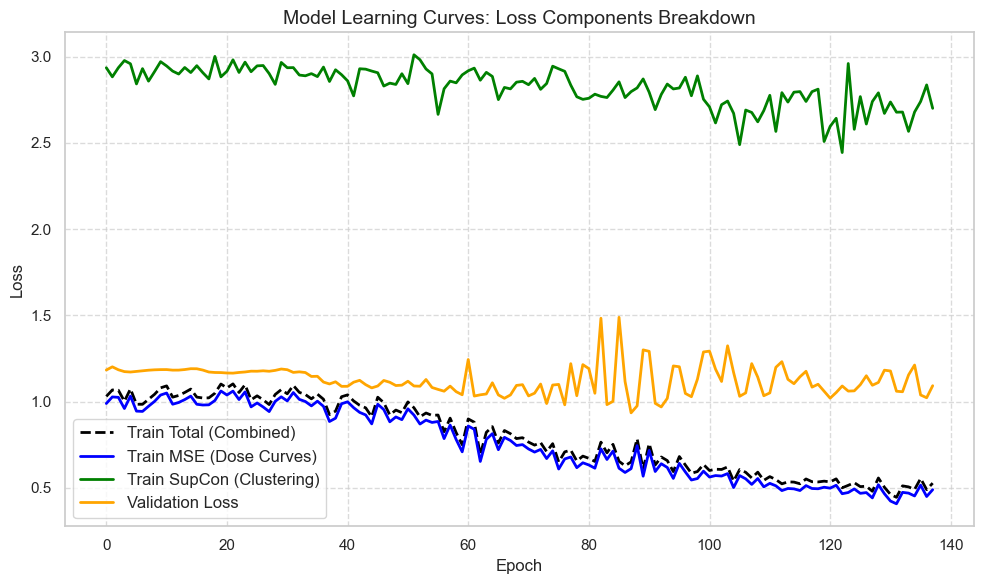

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



--- Top Predicted Selective Compounds (Ranked by Predicted AUC Differential) ---
                                              SMILES  Pred_ZBTB11_Selectivity  \
7  O=C1C2=CC=C(NC(CN(CC3)CCN3C4=CC=C(OC)C=C4)=O)C...               -25.828975   
6  O=C1C2=CC=C(NC(CN(CCCC3=CC=C(OC)C=C3)C4CCCC4)=...               -40.965912   
4  O=C(N1)CCC(N2C(C(NC3=CC(C4(CCC4)NCC5=CC(S(=O)(...               -66.338956   
3  O=C(N1)CCC(N2C(C(NC3=CC(C4(CCC4)NCC5=CC=C(S(=O...               -67.935671   
0  O=C1CCC(N2C(C(C=CC(NC(NC3(CCCC3)C(NCCC4=CC=C(O...               -72.135590   

   True_ZBTB11_Selectivity  Pred_ZBTB11_AUC  True_ZBTB11_AUC  
7              -222.320777       452.811217       450.723594  
6              -288.607287       441.801247       436.649134  
4                 1.011474       423.819710       420.347358  
3                 2.552514       422.713592       404.461537  
0              -141.692576       420.131196       438.465436  
Extracted fingerprints shape: (8, 150)


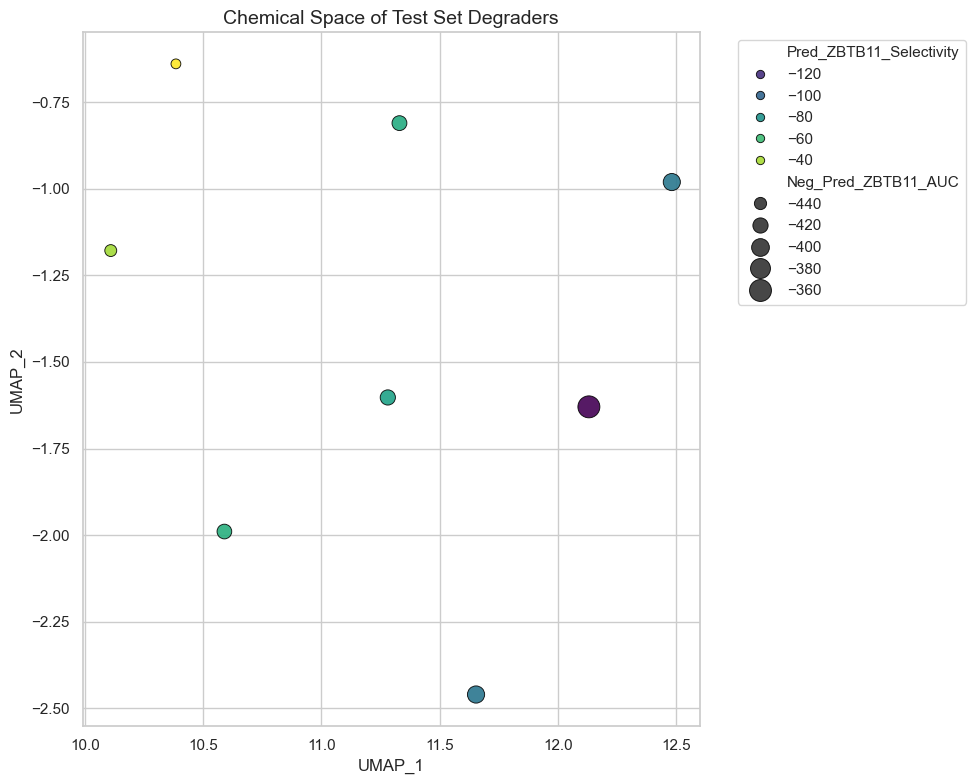


Overall Average Across All Concentrations -> RMSE: 18.353 | R²: -4.451

--- Regression Evaluation Metrics (Per Concentration) ---
    Endpoint  N_Valid_Points   RMSE    MAE      R²  Pearson_r
  zbtb11_3nM               8  1.040  0.890   0.346      0.780
 zbtb11_10nM               8  1.949  1.494  -0.777     -0.014
 zbtb11_30nM               8  2.940  1.921 -12.467      0.054
zbtb11_100nM               8  3.044  2.411  -0.715      0.937
zbtb11_300nM               8  6.119  4.482 -19.003      0.795
  zbtb11_1uM               8  9.290  7.311 -37.423     -0.302
  zbtb11_3uM               8  8.566  5.386  -6.017      0.182
 zbtb11_10uM               8  9.062  6.085  -3.170      0.456
 zbtb11_30uM               8 15.187 11.945  -0.071      0.336
zbtb11_100uM               8 29.327 24.851  -0.138      0.289
   ikzf1_3nM               8  7.480  4.621  -0.443     -0.353
  ikzf1_10nM               8 17.487 11.742  -0.725     -0.520
  ikzf1_30nM               8 29.316 20.826  -0.813     -0.596
 

In [37]:
# 1. Custom Supervised Contrastive Learning Model Wrapper
class SupConMPNN(MPNN):
    def __init__(self, message_passing, agg, ffn, d_h, supcon_weight, temperature, lr=1e-3):
        super().__init__(message_passing, agg, ffn)
        
        self.ntxent_loss = NTXentLoss(temperature=temperature)
        self.supcon_weight = supcon_weight
        self.lr = lr 
        
        self.projection_head = torch_nn.Sequential(
            torch_nn.Linear(d_h, d_h),
            torch_nn.ReLU(),
            torch_nn.Linear(d_h, 64)
        )

    def _hide_supcon_labels(self, batch): 
        new_Y = batch.Y[:, :20]
        new_w = batch.w[:, :20] if batch.w is not None and batch.w.dim() == 2 and batch.w.shape[1] > 20 else batch.w
        new_lt = batch.lt_mask[:, :20] if batch.lt_mask is not None and batch.lt_mask.dim() == 2 and batch.lt_mask.shape[1] > 20 else batch.lt_mask
        new_gt = batch.gt_mask[:, :20] if batch.gt_mask is not None and batch.gt_mask.dim() == 2 and batch.gt_mask.shape[1] > 20 else batch.gt_mask
        
        return batch._replace(Y=new_Y, w=new_w, lt_mask=new_lt, gt_mask=new_gt)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-4)
        
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, 
            T_max=200, 
            eta_min=1e-6
        )
        
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch"
            }
        }

    def training_step(self, batch, batch_idx):
        mod_batch = self._hide_supcon_labels(batch)
        
        H_v = self.message_passing(mod_batch.bmg, mod_batch.V_d)
        raw_fingerprints = self.agg(H_v, mod_batch.bmg.batch)
        
        if mod_batch.X_d is not None:
            combined_features = torch.cat([raw_fingerprints, mod_batch.X_d], dim=1)
        else:
            combined_features = raw_fingerprints
        
        preds = self.predictor(combined_features)
        
        targets = mod_batch.Y
        mask = ~torch.isnan(targets)
        mse_loss = F.mse_loss(preds[mask], targets[mask])
        
        raw_projections = self.projection_head(raw_fingerprints)
        projected_fps = F.normalize(raw_projections, p=2, dim=1)
        
        supcon_labels = batch.Y[:, 20]
        supcon_loss = self.ntxent_loss(projected_fps, supcon_labels) 
        
        total_loss = mse_loss + (self.supcon_weight * supcon_loss)
        
        self.log("train_mse_loss", mse_loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_supcon_loss", supcon_loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_total_loss", total_loss, on_step=False, on_epoch=True)
        
        return total_loss

    def validation_step(self, batch, batch_idx):
        mod_batch = self._hide_supcon_labels(batch)
        return super().validation_step(mod_batch, batch_idx)

    def test_step(self, batch, batch_idx):
        mod_batch = self._hide_supcon_labels(batch)
        return super().test_step(mod_batch, batch_idx)

    def predict_step(self, batch, *args, **kwargs):
        mod_batch = self._hide_supcon_labels(batch)
        return super().predict_step(mod_batch, *args, **kwargs)


# 2. HYPERPARAMETER TUNING WITH OPTUNA
full_transform = nn.UnscaleTransform.from_standard_scaler(output_scaler)

sliced_mean = full_transform.mean[..., :20]
sliced_scale = full_transform.scale[..., :20]

output_transform = nn.UnscaleTransform(
    mean=sliced_mean,
    scale=sliced_scale
)

def objective(trial):
    depth = trial.suggest_int("depth", 3, 5)
    d_h = trial.suggest_int("d_h", 50, 200, step=50)
    dropout = trial.suggest_float("dropout", 0.1, 0.3, step=0.1)
    n_layers = trial.suggest_int("n_layers", 2, 3)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    supcon_weight = trial.suggest_float("supcon_weight", 0.01, 0.2, log=True)
    temperature = trial.suggest_float("temperature", 0.05, 0.2)

    mp = nn.BondMessagePassing(depth=depth, d_h=d_h)
    agg = nn.MeanAggregation()

    ffn = nn.RegressionFFN(
        n_tasks=20,
        input_dim=mp.output_dim,
        hidden_dim=d_h,
        n_layers=n_layers,
        dropout=dropout,
        output_transform=output_transform
    )

    chemprop_model = SupConMPNN(
        mp, agg, ffn, 
        d_h=d_h, 
        supcon_weight=supcon_weight, 
        temperature=temperature,
        lr=lr
    )

    tune_early_stop = EarlyStopping(monitor="val_loss", patience=25, mode="min")

    trainer = pl.Trainer(
        accelerator="auto",
        max_epochs=100,
        enable_checkpointing=False,
        enable_progress_bar=False,
        logger=False,
        callbacks=[tune_early_stop]
    )
    trainer.fit(chemprop_model, train_loader, val_loader)

    return tune_early_stop.best_score.item()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)
print(f"Best hyperparameters found: {study.best_params}")


# 3. TRAIN FINAL MODEL & PLOT LOSS CURVES
best = study.best_params

final_mp = nn.BondMessagePassing(depth=best["depth"], d_h=best["d_h"])
final_agg = nn.MeanAggregation()

final_ffn = nn.RegressionFFN(
    n_tasks=20,
    input_dim=final_mp.output_dim,
    hidden_dim=best["d_h"],
    n_layers=best["n_layers"],
    dropout=best["dropout"],
    output_transform=output_transform
)

final_model = SupConMPNN(
    final_mp, final_agg, final_ffn, 
    d_h=best["d_h"], 
    supcon_weight=best["supcon_weight"], 
    temperature=best["temperature"],
    lr=best["lr"]
)

logger = CSVLogger("training_logs", name="chemprop_model")

final_early_stop = EarlyStopping(
    monitor="val_loss", 
    min_delta=0.00, 
    patience=50, 
    verbose=True, 
    mode="min"
)

final_trainer = pl.Trainer(
    accelerator="auto",
    min_epochs=100,
    max_epochs=200,
    enable_checkpointing=True,
    enable_progress_bar=True,
    logger=logger,
    callbacks=[final_early_stop]
)

final_trainer.fit(final_model, train_loader, val_loader)

metrics_file = f"{logger.log_dir}/metrics.csv"
metrics_df = pd.read_csv(metrics_file)

val_cols = [c for c in metrics_df.columns if 'val' in c.lower() and 'loss' in c.lower()]
val_col = val_cols[0] if val_cols else None

if val_col and 'train_mse_loss' in metrics_df.columns:
    train_mse = metrics_df[['epoch', 'train_mse_loss']].dropna().groupby('epoch').mean()
    train_supcon = metrics_df[['epoch', 'train_supcon_loss']].dropna().groupby('epoch').mean()
    train_total = metrics_df[['epoch', 'train_total_loss']].dropna().groupby('epoch').mean()
    val_loss = metrics_df[['epoch', val_col]].dropna().groupby('epoch').mean()

    plt.figure(figsize=(10, 6))
    
    plt.plot(train_total.index, train_total['train_total_loss'], label='Train Total (Combined)', color='black', linewidth=2, linestyle='--')
    plt.plot(train_mse.index, train_mse['train_mse_loss'], label='Train MSE (Dose Curves)', color='blue', linewidth=2)
    plt.plot(train_supcon.index, train_supcon['train_supcon_loss'], label='Train SupCon (Clustering)', color='green', linewidth=2)
    plt.plot(val_loss.index, val_loss[val_col], label='Validation Loss', color='orange', linewidth=2)

    plt.title("Model Learning Curves: Loss Components Breakdown", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig("learning_curves.png", dpi=300)
    plt.show()
else:
    print("\nError: Could not find the required train or validation loss columns in the logs.")


# 4. DEFINE TARGETS AND X-AXIS FOR INTEGRATION
concs = ['3nM', '10nM', '30nM', '100nM', '300nM', '1uM', '3uM', '10uM', '30uM', '100uM']
conc_molar = [3e-9, 10e-9, 30e-9, 100e-9, 300e-9, 1e-6, 3e-6, 10e-6, 30e-6, 100e-6]
log_conc = np.log10(conc_molar)

true_zbtb11_cols = [f'zbtb11_{c}' for c in concs]
true_ikzf1_cols = [f'ikzf1_{c}' for c in concs]
targets = true_zbtb11_cols + true_ikzf1_cols
pred_cols = [f'Pred_{t}' for t in targets]


# 5. PREDICT & CALCULATE TRUE AUC SELECTIVITY
preds = final_trainer.predict(final_model, test_loader)
preds_tensor = torch.concat(preds, axis=0)

test_smiles = [dp.name for dp in test_data[0]] 
true_targets = [dp.y[:20] for dp in test_data[0]] 

true_cols = true_zbtb11_cols + true_ikzf1_cols
test_results_df = pd.DataFrame(true_targets, columns=true_cols)
test_results_df.insert(0, 'SMILES', test_smiles)

pred_zbtb11_cols = [f'Pred_{t}' for t in true_zbtb11_cols]
pred_ikzf1_cols = [f'Pred_{t}' for t in true_ikzf1_cols]
test_results_df[pred_zbtb11_cols + pred_ikzf1_cols] = preds_tensor.numpy().reshape(-1, 20)

test_results_df['Pred_ZBTB11_AUC'] = test_results_df[pred_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)
test_results_df['Pred_IKZF1_AUC'] = test_results_df[pred_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)

test_results_df['True_ZBTB11_AUC'] = test_results_df[true_zbtb11_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)
test_results_df['True_IKZF1_AUC'] = test_results_df[true_ikzf1_cols].apply(
    lambda row: np.trapezoid(y=row.values, x=log_conc), axis=1
)

test_results_df['Pred_ZBTB11_Selectivity'] = test_results_df['Pred_IKZF1_AUC'] - test_results_df['Pred_ZBTB11_AUC']
test_results_df['True_ZBTB11_Selectivity'] = test_results_df['True_IKZF1_AUC'] - test_results_df['True_ZBTB11_AUC']

test_results_df = test_results_df.sort_values(by='Pred_ZBTB11_Selectivity', ascending=False)
test_results_df.to_csv("zbtb11_mgd_chemprop_output.csv", index=False)

print("\n--- Top Predicted Selective Compounds (Ranked by Predicted AUC Differential) ---")
print(test_results_df[['SMILES', 'Pred_ZBTB11_Selectivity', 'True_ZBTB11_Selectivity', 'Pred_ZBTB11_AUC', 'True_ZBTB11_AUC']].head())


# 6. EXTRACT LEARNED FINGERPRINTS FROM THE MODEL
final_model.cpu()
final_model.eval()

learned_fingerprints = []

with torch.no_grad():
    for batch in test_loader:
        molecule_embeddings = final_model.fingerprint(batch.bmg, batch.V_d, batch.X_d)
        learned_fingerprints.append(molecule_embeddings.numpy())

embeddings_array = np.vstack(learned_fingerprints)
print(f"Extracted fingerprints shape: {embeddings_array.shape}")


# 7. UMAP DIMENSIONALITY REDUCTION & PLOTTING
reducer = umap.UMAP(n_neighbors=min(15, len(embeddings_array) - 1), min_dist=0.1, metric='euclidean', random_state=42)
embeddings_2d = reducer.fit_transform(embeddings_array)

test_results_df = test_results_df.sort_index()

test_results_df['UMAP_1'] = embeddings_2d[:, 0]
test_results_df['UMAP_2'] = embeddings_2d[:, 1]

test_results_df['Neg_Pred_ZBTB11_AUC'] = -test_results_df['Pred_ZBTB11_AUC']

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
scatter = sns.scatterplot(
    data=test_results_df, x='UMAP_1', y='UMAP_2',
    hue='Pred_ZBTB11_Selectivity', palette='viridis',
    size='Neg_Pred_ZBTB11_AUC', sizes=(50, 250), alpha=0.9, edgecolor="black"
)
plt.title("Chemical Space of Test Set Degraders", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("chemprop_umap.png", dpi=300, bbox_inches='tight')
plt.show()


# 8. EVALUATE REGRESSION METRICS FOR ALL 20 DOSES
y_true_array = np.array([dp.y[:20] for dp in test_data[0]], dtype=float)
evaluation_results = []

for idx, (true_col, pred_col) in enumerate(zip(targets, pred_cols)):
    y_true = y_true_array[:, idx]
    y_pred = test_results_df[pred_col].values

    valid_mask = ~np.isnan(y_true)
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    if len(y_true_valid) > 1:
        rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
        mae = mean_absolute_error(y_true_valid, y_pred_valid)
        r2 = r2_score(y_true_valid, y_pred_valid)
        pearson_r, _ = pearsonr(y_true_valid, y_pred_valid)
    else:
        rmse, mae, r2, pearson_r = np.nan, np.nan, np.nan, np.nan

    evaluation_results.append({
        'Endpoint': true_col,
        'N_Valid_Points': len(y_true_valid),
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'R²': round(r2, 3),
        'Pearson_r': round(pearson_r, 3)
    })

metrics_df = pd.DataFrame(evaluation_results)
metrics_df.to_csv("zbtb11_mgd_chemprop_metrics.csv", index=False)

avg_rmse = metrics_df['RMSE'].mean()
avg_r2 = metrics_df['R²'].mean()
print(f"\nOverall Average Across All Concentrations -> RMSE: {avg_rmse:.3f} | R²: {avg_r2:.3f}")

print("\n--- Regression Evaluation Metrics (Per Concentration) ---")
print(metrics_df.to_string(index=False))

# Conclusions
## Observations: 
* Incorporating a contrastive learning header seems to slightly improve the predictive accuracy of the model.
* However, the regression metrics still seem to skew towards ZBTB11, leaving IKZF1 metrics high. I wonder if the shared model is being dominated by optimizing loss on ZBTB11 degradation, but not IKZF1 degradation.

## Future Directions:
* I want to incorporate AlphaFold3 modeling and interface scores into this pipeline and observe whether or not this will improve the predictive accuracy of both (or one) models.
* I may need to tinker around with adjusting the weights of the loss function to highly penalize error on protein abundances at higher concentrations (>=10 uM), since these are the concentrations where we should observe most potent degradation if a molecule is an active degrader.
* I am next going to try splitting the single FFN into two separate FFNs that both make predictions based on the same shared chemical fingerprint but train on the two different datasets: ZBTB11 or IKZF1.